# SDD1004 - Analyse des corrélations superficielles et exemples adversariaux

## Import

In [19]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, torch.nn.functional as F, numpy as np
import re
from lime.lime_text import LimeTextExplainer
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt


MODEL_PATH = "out/model_a"
SEED = 42
MAX_LENGTH = 256


tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)


# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # ouin... ben ca l'air que LIME est meilleur avec CPU plutot que MPS...
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Pour le correcteur si jamais il reexecute et qu'il aurait du GPU sinon ca va prendre CPU comme pour moi.....

print(f"Utilisation du device : {device}")
model.to(device).eval()


dataset = load_dataset("imdb")


def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


# HuggingFace IMDB a un sous-ensemble pour TRAIN, TEST et UNSUPERVISED...
test_ds = dataset["test"].map(tokenize_function, batched=True, remove_columns=["text"])

Utilisation du device : cpu


In [20]:
first_positive_review = dataset["test"].filter(lambda review: review["label"] == 1)[0]
first_negative_review = dataset["test"].filter(lambda review: review["label"] == 0)[0]

print("\nPREMIER AVIS POSITIF:\n")
print(f"Label: {first_positive_review['label']}\n")
print(f"Avis: {first_positive_review['text']}\n")

print("\nPREMIER AVIS NEGATIF:\n")
print(f"Label: {first_negative_review['label']}\n")
print(f"Avis: {first_negative_review['text']}")


PREMIER AVIS POSITIF:

Label: 1

Avis: Previous reviewer Claudio Carvalho gave a much better recap of the film's plot details than I could. What I recall mostly is that it was just so beautiful, in every sense - emotionally, visually, editorially - just gorgeous.<br /><br />If you like movies that are wonderful to look at, and also have emotional content to which that beauty is relevant, I think you will be glad to have seen this extraordinary and unusual work of art.<br /><br />On a scale of 1 to 10, I'd give it about an 8.75. The only reason I shy away from 9 is that it is a mood piece. If you are in the mood for a really artistic, very romantic film, then it's a 10. I definitely think it's a must-see, but none of us can be in that mood all the time, so, overall, 8.75.


PREMIER AVIS NEGATIF:

Label: 0

Avis: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is 

## 1. Identifier des erreurs dues à des corrélations superficielles (raccourci statistique)

**LIME** (*Local Interpretable Model-agnostic Explanations*) explique la prédiction d'un modèle sur un exemple donné en perturbant le texte (en masquant des mots aléatoirement) et en observant comment la confiance du modèle change...

### Principe
- Pour chaque mot dans un avis IMDB, LIME va estimer une contribution à la prédiction
- Un mot avec une contribution forte = le modèle réagit à sa présence seule.

### Résumé rapide de ce qui va suivre
1. Identification des mots les plus influents sur un petit sample d'avis IMDB avec l'aide de LIME
2. Aggregation des différentes contributions sur l'ensemble de l'échantillon
3. Visualisation des mots à corrélation superficielle, ceux qui sont dominant
4. Croisement des erreurs du modèle avec les mots suspects trouver juste avant pour identifier des cas problématiques potentiel

### Fonction de prédiction LIME et sampling pour l’analyse

- `lime_predict` : Une fonction wrapper, LIME peut pas utiliser directement le modèle de HuggingFace, donc ca prend un intermédiaire qui prend des textes et retourne les probabilités pour lime (retourner en array numpy...)
- Sample de 50 avis d'IMDB (25 pos + 25 neg), j'ai volontairement fait le sample vraiment petit mais LIME prend énormement de temps (500 perturbations * 50 textes d'avis = 25 000 call au modèle environs, avec mon pauvre ordinateur...)

In [21]:
# Prend une liste de textes et retourne les proba prédites par le modèle pour LIME (on passe les logits dans softmax)
# https://lime-ml.readthedocs.io/en/latest/lime.html - VOIR DOC OFFICIEL:
# explain_instance(text_instance, classifier_fn, labels=(1, ), top_labels=None, num_features=10, num_samples=5000, distance_metric='cosine', model_regressor=None)
#
# classifier_fn – classifier prediction probability function, which takes a list of d strings and outputs a (d, k) numpy array with prediction probabilities, where k is the number of classes. For ScikitClassifiers , this is classifier.predict_proba.
#
def lime_predict(text_list):
    tokenized_inputs = tokenizer(list(text_list), truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        model_logits = model(**tokenized_inputs).logits
    return F.softmax(model_logits, dim=-1).cpu().numpy()


explainer = LimeTextExplainer(class_names=["NEGATIVE", "POSITIVE"], random_state=SEED)


NUM_SAMPLES_PER_CLASS = 25


positive_sample = dataset["test"].filter(lambda x: x["label"] == 1).shuffle(seed=SEED).select(range(NUM_SAMPLES_PER_CLASS))
negative_sample = dataset["test"].filter(lambda x: x["label"] == 0).shuffle(seed=SEED).select(range(NUM_SAMPLES_PER_CLASS))


lime_analysis_sample = list(positive_sample) + list(negative_sample)

### Mots les plus associés à des corrélations superficielles avec LIME
- Pour chaque avis d'IMDB du sample, LIME cache/masque des mots, un par un et regarde comment la confiance change
- Si le fait d'enlever un mot comme par exemple "waste" fait monter la confiance POSITIVE de 0.3, ca veut dire que "waste" a une contribution de -0.3 vers POSITIVE (un signal négatif tres fort)

.

- Aggrégation des contributions mot par mot sur les 50 textes d'avis.
- À la fin, `df_lime` contient pour chaque mot, sa contribution moyenne sur toutes les avis ou il a apparu.
- Les `top_neg_words` et `top_pos_words` sont les mots que le modèle fait de la surpondération dessu, c'est des mots qui pourraient causer des corrélations superficielles...

In [22]:
# Agregation des contributions LIME sur le sample → mots influents
# Prend environ 10 à 15 min a executer....

STOP_WORDS_MAIN = {"the","a","an","and","or","but","in","on","at","to","for","of","with","is","was","it","i","this","that"}


STOP_WORDS = STOP_WORDS_MAIN | {
    "t", "s", "re", "ve", "ll", "don", "doesn", "didn", "isn",
    "wasn", "weren", "won", "can", "could", "would", "should",
    "its", "be", "as", "by", "an", "so", "if", "up", "about",
    "out", "just", "my", "me", "we", "he", "she", "they", "them",
    "his", "her", "their", "our", "your", "you", "am", "are", "has",
    "have", "had", "do", "did", "been", "very", "more", "than",
    "there", "what", "when", "which", "who", "will", "into", "also",
    "br", "movie"
}


# utilise LIME sur chaque texte du sample et ajoute les poids des mots importants, en ignorant les stop words
word_contributions = defaultdict(list)


for review in lime_analysis_sample: # pour chaque avis 500 essaie de perturbation LIME, garde 10 mots (les plus influent)
    explanation = explainer.explain_instance(review["text"], lime_predict, num_features=10, num_samples=500, labels=[1])
    for word, lime_weight in explanation.as_list(label=1):
        cleaned_word = re.sub(r"[^a-z]", "", word.lower())
        if cleaned_word and cleaned_word not in STOP_WORDS:
            word_contributions[cleaned_word].append(lime_weight)


"""
SQL Equivalent: (j'ai donné le SQL qui suit a ChatGPT pour qu'il me génnère la petite portion de code qui suit, j'ai eu de la difficulté avec la syntaxe...)

SELECT
  cleaned_word,
  AVG(contribution) AS mean_contribution,
  COUNT(*) AS occurrence_count
FROM word_contributions
GROUP BY cleaned_word
HAVING COUNT(*) >= 3
ORDER BY mean_contribution ASC;
"""
df_lime = (
    pd.DataFrame({
        cleaned_word: {
            "mean_contribution": np.mean(contributions),
            "occurrence_count":  len(contributions)
        }
        for cleaned_word, contributions in word_contributions.items() if len(contributions) >= 3 # mot qui apparait minimum 3 fois
    }).T
    .astype(float)
    .sort_values("mean_contribution")
)


top_neg_words = set(df_lime[df_lime["mean_contribution"] < 0].head(10).index)
top_pos_words = set(df_lime[df_lime["mean_contribution"] > 0].tail(10).index)

print(f"Signal NEGATIF : {top_neg_words}")
print(f"Signal POSITIF : {top_pos_words}")

Signal NEGATIF : {'terrible', 'nothing', 'not', 'no', 'really', 'bad', 'one', 'film'}
Signal POSITIF : {'nice', 'years', 'great', 'worth'}


#### Schema des différents mots probables à causer des corrélations superficielles

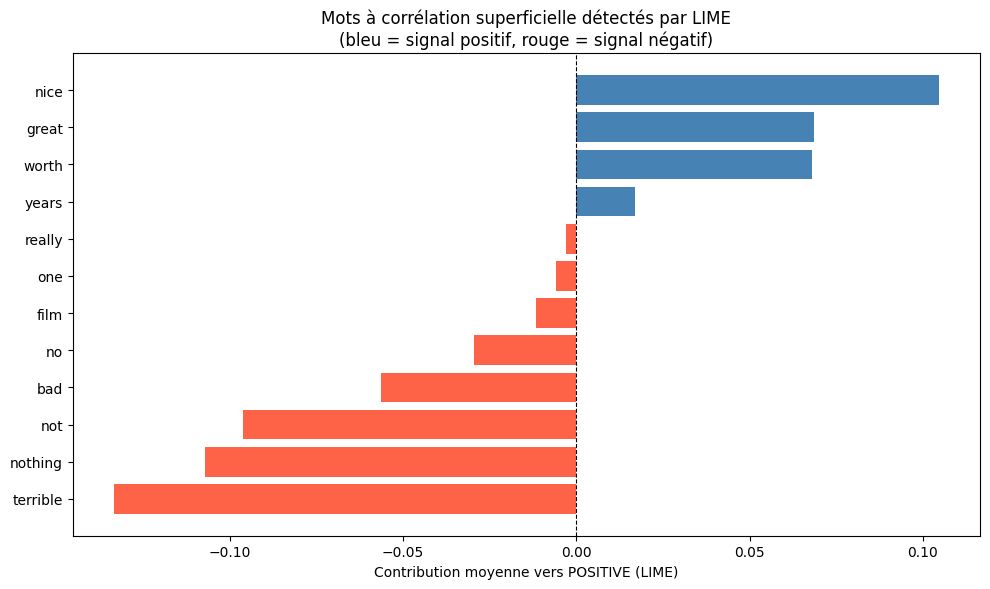

In [23]:
# schema des mots - correlation superficielle

df_lime_clean = df_lime[~df_lime.index.isin(STOP_WORDS)].copy() # avec panda en python la tilde c'est comme le ! en Java...

num_words_with_strongest_contributions = 20
strongest_contributing_words_df = df_lime_clean.reindex(
    df_lime_clean["mean_contribution"].abs().sort_values(ascending=False).head(num_words_with_strongest_contributions).index
).sort_values("mean_contribution")

strongest_contributing_words_df["mean_contribution"] = strongest_contributing_words_df["mean_contribution"].astype(float)
colors = ["steelblue" if mean_contribution > 0 else "tomato" for mean_contribution in strongest_contributing_words_df["mean_contribution"]]

figure, axix = plt.subplots(figsize=(10, 6))
axix.barh(strongest_contributing_words_df.index, strongest_contributing_words_df["mean_contribution"], color=colors)
axix.axvline(0, color="black", linewidth=0.8, linestyle="--")
axix.set_xlabel("Contribution moyenne vers POSITIVE (LIME)")
axix.set_title(
    "Mots à corrélation superficielle détectés par LIME\n"
    "(bleu = signal positif, rouge = signal négatif)"
)
plt.tight_layout()
plt.show()

### A la recherche d'erreurs associées à des corrélations superficielles

- Maintenant il faut regarder juste les avis ou le modele c'est tromper, et parmi ceux la, juste ceux ou un mot important va dans le sens inverse du vrai label, avec un poids superrieur a 0.05

Exemple de ce qui faut chercher:
- Vrai label : POSITIVE
- Le texte contient "terrible" ou "bad"
- LIME confirme que le mot pousse fort vers NEGATIVE
- Le modele fait une prediction comme quoi ca serait NEGATIVE
→ Ca serait un erreur qui serait peut-etre causer par correlation superficielle et pas par incomprehension du texte

In [24]:
# Croisement erreurs du model + mots suspects ------ LIME
shallow_correlation_errors = []

for review in lime_analysis_sample:
    review_text, true_label = review["text"], review["label"]
    prediction_probs = lime_predict([review_text])[0]
    predicted_label = int(prediction_probs.argmax())

    if predicted_label == true_label:
        continue

    explanation = explainer.explain_instance(review_text, lime_predict, num_features=10, num_samples=500, labels=[1])
    lime_weights_by_word = {
        re.sub(r"[^a-z]", "", word.lower()): round(weight, 4)
        for word, weight in explanation.as_list(label=1)
        if re.sub(r"[^a-z]", "", word.lower()) not in STOP_WORDS
    }

    suspicious_words = {
        word: weight for word, weight in lime_weights_by_word.items()
        if (true_label == 1 and word in top_neg_words and weight < -0.05) or
           (true_label == 0 and word in top_pos_words and weight > 0.05)
    }

    if suspicious_words:
        shallow_correlation_errors.append({
            "text_snippet":      review_text[:300].replace("\n", " "),
            "true_label":        "POSITIVE" if true_label == 1 else "NEGATIVE",
            "predicted_label":   "POSITIVE" if predicted_label == 1 else "NEGATIVE",
            "positive_conf":     round(float(prediction_probs[1]), 4),
            "suspicious_words":  suspicious_words,
        })

print(f"{len(shallow_correlation_errors)} erreurs superficielles sur {len(lime_analysis_sample)} reviews.")

2 erreurs superficielles sur 50 reviews.


#### Parmis les 50 avis du sample, il y avait 6 erreurs de prédiction, et parmi ces 6 erreurs, 2 sont associées à 1 mots à corrélation superficielle

In [33]:
correct_count = 0
wrong_count = 0

for review in lime_analysis_sample:
    review_text = review["text"]
    true_label = review["label"]

    prediction_probs = lime_predict([review_text])[0]
    predicted_label = int(prediction_probs.argmax())

    if predicted_label == true_label:
        correct_count += 1
    else:
        wrong_count += 1

print(f"Bien prédits : {correct_count}")
print(f"Mal prédits  : {wrong_count}")
print(f"Total        : {correct_count + wrong_count}")

Bien prédits : 44
Mal prédits  : 6
Total        : 50


#### Affichage des cas d'erreurs liées à des corrélations superficielles

In [25]:
for error_index, error_case in enumerate(shallow_correlation_errors):
    print(f"\n{'='*70}")
    print(f"Cas #{error_index+1}  |  Vrai: {error_case['true_label']}  →  Prédit: {error_case['predicted_label']}  (conf POS={error_case['positive_conf']})")
    print(f"Mots suspects : {error_case['suspicious_words']}")
    print(f"Extrait : {error_case['text_snippet']}...")


Cas #1  |  Vrai: POSITIVE  →  Prédit: NEGATIVE  (conf POS=0.0669)
Mots suspects : {'not': -0.1237}
Extrait : Ironically, what makes John Carpenter's "The Thing" such an entertaining sci-fi film are its genre-defying elements of mystery, suspense, and tight plot structure. It puts to shame such films as "Aliens" or "Armageddon" that are content to inundate the viewer with special effects while their plots r...

Cas #2  |  Vrai: NEGATIVE  →  Prédit: POSITIVE  (conf POS=0.5602)
Mots suspects : {'nice': 0.1141}
Extrait : very straight - not happy with the movie.<br /><br />The main center of the movie is the story where the lady is the mother of all the snacks and all the things.<br /><br />If they can more explain that how this is happening and all the stuff then it was quite a fun and more rating for this movie.<b...


## 2. Construire des exemples adversariaux

#### Petite note personnelle:
> Un exemple adversarial c'est un texte modifié (le plus minimalement possible par exemple avec juste un mot) par rapport au texte original pour tromper le modèle, mais ca doit pas changer le sens global du texte...

#### L'idée derrière ce qui va suivre
Utiliser les résultâts qu'on viens juste d'avoir avec les corrélations superficielles, si le modèle réagit a un mot en particulier indépendamment du contexte ca veut dire qu'injecter `lack` dans un avis POSITIF devrait être suffisant pour faire basculer la prédiction vers NÉGATIF

### Sélection des mots à injecter dans les exemples adversariaux

In [28]:
# prend un avis, demande la pred et retourne --- label predit, proba positif et proba negatif
def predict_single(text):
    """Retourne (label_str, conf_pos, conf_neg)"""
    prediction = lime_predict([text])[0]
    label = "POSITIVE" if prediction.argmax() == 1 else "NEGATIVE"
    return label, round(float(prediction[1]), 4), round(float(prediction[0]), 4)


# Top 3 des mots NEGATIF et top 3 des POSITIF avec le plus d'influence pris avec les resultat donner par LIME...
INJECT_NEG = ['terrible', 'nothing', 'not']
INJECT_POS = ['nice', 'great', 'worth']

print(f"Mots negatifs a injecter : {INJECT_NEG}")
print(f"Mots positifs a injecter : {INJECT_POS}")

Mots negatifs a injecter : ['terrible', 'nothing', 'not']
Mots positifs a injecter : ['nice', 'great', 'worth']


### Sélection des avis de base correctement prédite par le modèle

In [29]:
# Trouver des avis IMDB bien prédit par le modèle comme base pour les exemples adversariaux

correctly_classified_positive = []  # avis POSITIVES bien classifier → pour injecter un mot negatif
correctly_classified_negative = []  # avis NÉGATIVES bien classifier → pour injecter un mot positif

SAMPLES_PER_CLASS = 25

for review in dataset["test"]:
    review_text, true_label = review["text"], review["label"]
    predicted_label_str, positive_conf, _ = predict_single(review_text)
    predicted_label = 1 if predicted_label_str == "POSITIVE" else 0

    if predicted_label != true_label: # On garde pas si c'est pas bien prédit, skip...
        continue

    # short extrait pour (la premiere phrase)
    first_sentence = review_text.split(".")[0] + "."

    if true_label == 1 and positive_conf > 0.85 and len(correctly_classified_positive) < SAMPLES_PER_CLASS:
        correctly_classified_positive.append({"text": review_text, "first_sentence": first_sentence, "positive_conf": positive_conf})

    if true_label == 0 and positive_conf < 0.15 and len(correctly_classified_negative) < SAMPLES_PER_CLASS:
        correctly_classified_negative.append({"text": review_text, "first_sentence": first_sentence, "positive_conf": positive_conf})

print(f"Bases positives trouver : {len(correctly_classified_positive)}")
print(f"Bases negatives trouver : {len(correctly_classified_negative)}")

Bases positives trouver : 25
Bases negatives trouver : 25


### Génération et évaluation des exemples adversariaux par injections des mots à corrélation superficielle

In [30]:
# generation et evaluation des exemples adversariaux

# TODO: Si j'ai le temps, écrire une function pourrait être vraiment plus clean, idée de la signature pour refactoring: generate_adversarial_cases(base_review, injected_words, injection_type)

adversarial_results = []

# premier cas : avis POSITIVE + injection d'un mot negatif
for base_review in correctly_classified_positive:
    original_text = base_review["text"]
    for negative_word in INJECT_NEG:
        modified_text = negative_word + ". " + original_text

        original_label,  original_positive_conf,  _ = predict_single(original_text)
        modified_label,  modified_positive_conf,  _ = predict_single(modified_text)

        adversarial_results.append({
            "injection_type":         "POS + injection NEG",
            "injected_word":          negative_word,
            "original_label":         original_label,
            "modified_label":         modified_label,
            "original_positive_conf": original_positive_conf,
            "modified_positive_conf": modified_positive_conf,
            "confidence_delta":       round(modified_positive_conf - original_positive_conf, 4),
            "prediction_flipped":     original_label != modified_label,
            "review_excerpt":         base_review["first_sentence"][:120],
        })

# deuxieme cas : avis NEGATIVE + injection d'un mot positif
for base_review in correctly_classified_negative:
    original_text = base_review["text"]
    for positive_word in INJECT_POS:
        modified_text = positive_word + ". " + original_text

        original_label,  original_positive_conf,  _ = predict_single(original_text)
        modified_label,  modified_positive_conf,  _ = predict_single(modified_text)

        adversarial_results.append({
            "injection_type":         "NEG + injection POS",
            "injected_word":          positive_word,
            "original_label":         original_label,
            "modified_label":         modified_label,
            "original_positive_conf": original_positive_conf,
            "modified_positive_conf": modified_positive_conf,
            "confidence_delta":       round(modified_positive_conf - original_positive_conf, 4),
            "prediction_flipped":     original_label != modified_label,
            "review_excerpt":         base_review["first_sentence"][:120],
        })

df_adversarial = pd.DataFrame(adversarial_results)

total_flipped = df_adversarial["prediction_flipped"].sum()
print(f"\n{total_flipped} / {len(df_adversarial)} adversariaux ont fait basculer totalement la prédiction")
print(f"Delta moyen de confiance : {df_adversarial['confidence_delta'].abs().mean():.4f}")


17 / 150 adversariaux ont fait basculer totalement la prédiction
Delta moyen de confiance : 0.1169


#### NOTES PERSONNELLES:
- Le delta moyen de confiance c'est de combien la confiance du modele a changer apres l'injection d'un mot.
- Donc en moyenne, le modele est plutot stable, mais on va voir que dans certaine situation, l'injection du mot a eu un impact enorme et a fais basculer la prediction, soit 17 cas sur 150, soit 11.33% des cas...

### Affichage des renversement total de prédiction

In [31]:
# Affichage des cas ou la pred a basculer

flipped_predictions = df_adversarial[df_adversarial["prediction_flipped"]].reset_index(drop=True)

for flip_index, flip_case in flipped_predictions.iterrows():
    print(f"\n{'='*70}")
    print(f"Type     : {flip_case['injection_type']}")
    print(f"Mot      : '{flip_case['injected_word']}'")
    print(f"Avant    : {flip_case['original_label']} (conf POS={flip_case['original_positive_conf']})")
    print(f"Apres    : {flip_case['modified_label']} (conf POS={flip_case['modified_positive_conf']})")
    print(f"Delta    : {flip_case['confidence_delta']:+.4f}")
    print(f"Extrait  : {flip_case['review_excerpt']}...")


Type     : POS + injection NEG
Mot      : 'terrible'
Avant    : POSITIVE (conf POS=0.9829)
Apres    : NEGATIVE (conf POS=0.0169)
Delta    : -0.9660
Extrait  : This is my first Deepa Mehta film....

Type     : POS + injection NEG
Mot      : 'terrible'
Avant    : POSITIVE (conf POS=0.9939)
Apres    : NEGATIVE (conf POS=0.2977)
Delta    : -0.6962
Extrait  : I finally watched the third film in Mehta's trilogy: "Fire"....

Type     : POS + injection NEG
Mot      : 'terrible'
Avant    : POSITIVE (conf POS=0.9968)
Apres    : NEGATIVE (conf POS=0.3785)
Delta    : -0.6183
Extrait  : one of best movies ever....

Type     : POS + injection NEG
Mot      : 'terrible'
Avant    : POSITIVE (conf POS=0.9939)
Apres    : NEGATIVE (conf POS=0.1753)
Delta    : -0.8186
Extrait  : It is more a subtle story of the fact that in Indian household how most decisions are taken by the man, how no attention...

Type     : POS + injection NEG
Mot      : 'terrible'
Avant    : POSITIVE (conf POS=0.9842)
Apres    : NEG

### Schema de l’impact de chaque mot sur les exemples adversariaux

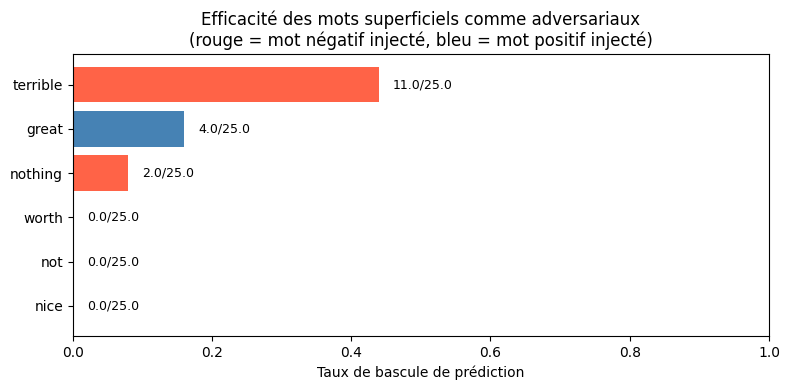

In [32]:
# SCHEMA : taux de renversement de prediction par mot injecte

flip_rate_by_word = (
    df_adversarial.groupby("injected_word")["prediction_flipped"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "total_flipped", "count": "total_attempts"})
)
flip_rate_by_word["flip_rate"] = flip_rate_by_word["total_flipped"] / flip_rate_by_word["total_attempts"]
flip_rate_by_word = flip_rate_by_word.sort_values("flip_rate", ascending=True)

colors = ["steelblue" if word in top_pos_words else "tomato" for word in flip_rate_by_word.index]

figure, axis = plt.subplots(figsize=(8, 4))
axis.barh(flip_rate_by_word.index, flip_rate_by_word["flip_rate"], color=colors)
axis.set_xlabel("Taux de bascule de prédiction")
axis.set_title("Efficacité des mots superficiels comme adversariaux\n(rouge = mot négatif injecté, bleu = mot positif injecté)")
axis.set_xlim(0, 1)
for bar_index, (word, row) in enumerate(flip_rate_by_word.iterrows()):
    axis.text(row["flip_rate"] + 0.02, bar_index, f"{row['total_flipped']}/{row['total_attempts']}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Analyse des causes

1. Certains mots sont trop associés à une classe (positive/negative)
2. Le modèle a appris ces raccourcis statistiques
3. Un mot isolé peut dominer le reste du texte au moment de la prédiction
4. Le contexte complet des avis est pas toujours assez pris en compte
5. La limite de 256 tokens peut aggraver le problème

> Voir le rapport pour l'analyse détaillée et les exemples concrets associés à chaque cause.

## 4. Proposition d'améliorations

1. Utiliser un sample beaucoup plus gros et trouver plus de mots influents avec LIME
2. Ajouter des exemples adversariaux directement au dataset avant l'entraînement
3. Augmenter la longueur maximale des séquences (512) pour garder plus de contexte
4. Tester avec un modèle plus robuste que DistilBERT
5. Ajouter des avis (avec leurs labels) plus complexes au dataset d'entraînement (avec négation, formulation confuse (avec ironie, sarcasme, etc.))

> Voir le rapport pour une explication détaillée de chaque amélioration proposée.